<a href="https://colab.research.google.com/github/Navyam-Raushan/Machine-Learning-Models/blob/main/Mini_project_LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("hello")

hello


# Task
Implement a Retrieval Decision Module by loading the `retrieval_decision_dataset_500_samples.csv` dataset, performing necessary preprocessing including null checks and label encoding, and splitting it into training and testing sets. Then, apply TF-IDF vectorization to the 'question' column, train a Logistic Regression model on the vectorized data, and evaluate its performance using accuracy, precision, recall, F1-score, a confusion matrix, and a classification report. Afterward, create and test a `predict_retrieval(query: str)` function with example queries 'Tell me about India' and 'Write a poem about friendship', and finally save the trained model and the TF-IDF vectorizer for future use.

## Load Dataset and Preprocess Data

### Subtask:
Load the `retrieval_decision_dataset_500_samples.csv` using pandas, check for null values, encode the 'retrieval_needed' labels, and perform an 80/20 train-test split on the dataset. Ensure clean, modular Python code with clear comments.


**Reasoning**:
The subtask requires loading the dataset, checking for null values, encoding a categorical column, and then splitting the data into training and testing sets. This code block will perform all these actions in a sequential manner, importing necessary libraries first.



In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 2. Load the retrieval_decision_dataset_500_samples.csv file into a pandas DataFrame named df.
df = pd.read_csv('/content/retrieval_decision_dataset_500_samples.csv')
print("Dataset loaded successfully. First 5 rows:")
print(df.head())

# 3. Check for any missing values in the DataFrame using .isnull().sum() and print the result.
print("\nMissing values in each column:")
print(df.isnull().sum())

# 4. Initialize a LabelEncoder from sklearn.preprocessing.
# 5. Apply the LabelEncoder to the 'retrieval_needed' column of the DataFrame to convert categorical labels into numerical ones.
encoder = LabelEncoder()
df['retrieval_needed'] = encoder.fit_transform(df['retrieval_needed'])
print("\n'retrieval_needed' column encoded. First 5 rows with encoded labels:")
print(df.head())

# 6. Split the DataFrame into training and testing sets.
# The features (X) should be the 'question' column and the target (y) should be the encoded 'retrieval_needed' column.
# Use a test size of 0.2 (20%) and a random_state for reproducibility.
X = df['question']
y = df['retrieval_needed']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nData split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Dataset loaded successfully. First 5 rows:
                                      question  retrieval_needed
0                  Write a poem about courage.                 0
1          When did Germany gain independence?                 1
2                    What is the height of K2?                 1
3  Name the Prime Minister of Germany in 2020.                 1
4                 Describe a beautiful sunset.                 0

Missing values in each column:
question            0
retrieval_needed    0
dtype: int64

'retrieval_needed' column encoded. First 5 rows with encoded labels:
                                      question  retrieval_needed
0                  Write a poem about courage.                 0
1          When did Germany gain independence?                 1
2                    What is the height of K2?                 1
3  Name the Prime Minister of Germany in 2020.                 1
4                 Describe a beautiful sunset.                 0

Data split into t

## Feature Engineering with TF-IDF

### Subtask:
Apply TF-IDF vectorization to the 'question' column of the training data to convert text queries into numerical features. Fit the TF-IDF vectorizer on the training data and transform both training and testing data.


**Reasoning**:
The subtask requires applying TF-IDF vectorization to the 'question' column. This involves importing `TfidfVectorizer`, initializing it, fitting it on the training data (`X_train`), and then transforming both the training and testing data (`X_train` and `X_test`) into numerical features.



In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 2. Instantiate a TfidfVectorizer object.
vectorizer = TfidfVectorizer()

# 3. Fit the vectorizer to the training data (X_train) using the .fit() method.
vectorizer.fit(X_train)

# 4. Transform both the training data (X_train) and the testing data (X_test)
#    using the fitted vectorizer's .transform() method.
#    Store the transformed data in new variables, X_train_tfidf and X_test_tfidf.
X_train_tfidf = vectorizer.transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF vectorization complete.")
print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

TF-IDF vectorization complete.
Shape of X_train_tfidf: (400, 167)
Shape of X_test_tfidf: (100, 167)


## Train Logistic Regression Model

### Subtask:
Train a Logistic Regression model using the TF-IDF vectorized training data and the corresponding labels. This choice aligns with the simplicity and efficiency requirements, avoiding deep learning or large GPU training.


**Reasoning**:
The subtask requires training a Logistic Regression model. This step will import the necessary class, instantiate the model, and then fit it to the TF-IDF vectorized training data.



In [4]:
from sklearn.linear_model import LogisticRegression

# 2. Instantiate a LogisticRegression model with random_state=42 for reproducibility.
model = LogisticRegression(random_state=42, solver='liblinear') # Added solver for older sklearn versions

# 3. Train the model using the fit() method with X_train_tfidf and y_train.
model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Evaluate Model Performance

### Subtask:
Evaluate the trained Logistic Regression model using the test data. Calculate and print the accuracy, precision, recall, F1-score, confusion matrix, and a classification report. This will provide a comprehensive understanding of the model's predictive capabilities.

**Reasoning**:
The subtask requires evaluating the trained model. This step will use the trained Logistic Regression model to make predictions on the test data and then calculate various classification metrics such as accuracy, precision, recall, F1-score, confusion matrix, and a classification report to assess its performance.



In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 2. Make predictions on the test data (X_test_tfidf).
y_pred = model.predict(X_test_tfidf)

# 3. Calculate and print the accuracy score.
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# 4. Calculate and print the precision score.
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")

# 5. Calculate and print the recall score.
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall:.4f}")

# 6. Calculate and print the F1-score.
f1 = f1_score(y_test, y_pred)
print(f"F1-Score: {f1:.4f}")

# 7. Generate and print the confusion matrix.
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# 8. Generate and print the classification report.
class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)


Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000

Confusion Matrix:
[[50  0]
 [ 0 50]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



## Create and Test `predict_retrieval` Function

### Subtask:
Create a Python function named `predict_retrieval(query: str)` that preprocesses a given query, vectorizes it using the fitted TF-IDF vectorizer, and then uses the trained Logistic Regression model to predict whether retrieval is needed (0 for no retrieval, 1 for retrieval). Test this function with example queries: 'Tell me about India' and 'Write a poem about friendship'.

## Create and Test `predict_retrieval` Function

### Subtask:
Create a Python function named `predict_retrieval(query: str)` that preprocesses a given query, vectorizes it using the fitted TF-IDF vectorizer, and then uses the trained Logistic Regression model to predict whether retrieval is needed (0 for no retrieval, 1 for retrieval). Test this function with example queries: 'Tell me about India' and 'Write a poem about friendship'.

**Reasoning**:
The subtask requires creating and testing a `predict_retrieval` function. This code block will define the function to preprocess, vectorize, and predict for a given query, and then test it with the specified example queries.



In [6]:
def predict_retrieval(query: str):
    """
    Predicts whether retrieval is needed for a given query.

    Args:
        query (str): The input query string.

    Returns:
        int: 0 if retrieval is not needed, 1 if retrieval is needed.
    """
    # Preprocess and vectorize the query
    query_tfidf = vectorizer.transform([query])

    # Make prediction using the trained model
    prediction = model.predict(query_tfidf)[0]

    return prediction

# Test the function with example queries
example_queries = [
    'Tell me about India',
    'Write a poem about friendship',
    'Who is President of USA',
    "Write an essay about Cow"


]

print("\nTesting predict_retrieval function:")
for query in example_queries:
    prediction = predict_retrieval(query)
    retrieval_status = "needed" if prediction == 1 else "not needed"
    print(f"Query: '{query}' -> Retrieval: {retrieval_status} (Encoded: {prediction})")


Testing predict_retrieval function:
Query: 'Tell me about India' -> Retrieval: not needed (Encoded: 0)
Query: 'Write a poem about friendship' -> Retrieval: not needed (Encoded: 0)
Query: 'Who is President of USA' -> Retrieval: needed (Encoded: 1)
Query: 'Write an essay about Cow' -> Retrieval: not needed (Encoded: 0)


## Save Model and Vectorizer

### Subtask:
Save the trained Logistic Regression model and the TF-IDF vectorizer to disk for future use. This will allow the model to be loaded and used for predictions without needing to re-train or re-vectorize the data.


## Evaluate Model on New Edge Test Data

### Subtask:
Load the `edge_100_test.xlsx` file, preprocess the data, vectorize the 'question' column using the existing TF-IDF vectorizer, make predictions using the trained Logistic Regression model, and then evaluate its performance. Ensure no data leakage by using already fitted components.

**Reasoning**:
This step loads the new dataset, applies the same label encoding and TF-IDF vectorization as done on the original training data (to prevent data leakage), and then uses the already trained model to predict and evaluate performance on this new, unseen data.

In [7]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 1. Load the edge_100_test.xlsx file into a pandas DataFrame.
df_edge = pd.read_excel('/content/edge_100_test.xlsx')
print("Edge test dataset loaded successfully. First 5 rows:")
print(df_edge.head())

# 2. Extract features (X) and target (y).
X_edge_test = df_edge['question']
y_edge_test = df_edge['retrieval_needed']

# 3. Encode the 'retrieval_needed' labels using the *already fitted* encoder.
# Ensure the encoder is available from previous steps.
# If 'encoder' is not in global scope, uncomment and run: encoder = joblib.load('path/to/encoder.joblib')
y_edge_test_encoded = encoder.transform(y_edge_test)
print("\n'retrieval_needed' column of edge test data encoded. First 5 encoded labels:")
print(y_edge_test_encoded[:5])

# 4. Vectorize the 'question' column using the *already fitted* TF-IDF vectorizer.
# Ensure 'vectorizer' is available from previous steps.
# If 'vectorizer' is not in global scope, uncomment and run: vectorizer = joblib.load('path/to/vectorizer.joblib')
X_edge_test_tfidf = vectorizer.transform(X_edge_test)
print(f"\nShape of X_edge_test_tfidf: {X_edge_test_tfidf.shape}")

# 5. Make predictions on the edge test data using the *already trained* model.
# Ensure 'model' is available from previous steps.
# If 'model' is not in global scope, uncomment and run: model = joblib.load('path/to/model.joblib')
y_edge_pred = model.predict(X_edge_test_tfidf)

# 6. Evaluate the model's performance on the edge test data.
print("\n--- Model Performance on Edge Test Data ---")

edge_accuracy = accuracy_score(y_edge_test_encoded, y_edge_pred)
print(f"Accuracy: {edge_accuracy:.4f}")

edge_precision = precision_score(y_edge_test_encoded, y_edge_pred)
print(f"Precision: {edge_precision:.4f}")

edge_recall = recall_score(y_edge_test_encoded, y_edge_pred)
print(f"Recall: {edge_recall:.4f}")

edge_f1 = f1_score(y_edge_test_encoded, y_edge_pred)
print(f"F1-Score: {edge_f1:.4f}")

edge_conf_matrix = confusion_matrix(y_edge_test_encoded, y_edge_pred)
print("\nConfusion Matrix:")
print(edge_conf_matrix)

edge_class_report = classification_report(y_edge_test_encoded, y_edge_pred)
print("\nClassification Report:")
print(edge_class_report)

Edge test dataset loaded successfully. First 5 rows:
                                            question  retrieval_needed
0  1. Analyze whether Indiaâ€™s current economic ...                 1
1  2. Write a persuasive speech about why economi...                 0
2  3. Compare Indiaâ€™s GDP with Chinaâ€™s and ex...                 1
3  4. Discuss whether democracy is better than mo...                 0
4  5. Explain the historical background of the Is...                 1

'retrieval_needed' column of edge test data encoded. First 5 encoded labels:
[1 0 1 0 1]

Shape of X_edge_test_tfidf: (100, 167)

--- Model Performance on Edge Test Data ---
Accuracy: 0.8600
Precision: 0.8214
Recall: 0.9200
F1-Score: 0.8679

Confusion Matrix:
[[40 10]
 [ 4 46]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.80      0.85        50
           1       0.82      0.92      0.87        50

    accuracy                           0.86       100

In [8]:
# 7. Add the predicted labels to the edge test DataFrame.
df_edge['predicted_retrieval'] = y_edge_pred

# 8. Save the DataFrame with predictions to a new Excel file.
output_filename = 'edge_100_test_with_predictions.xlsx'
df_edge.to_excel(output_filename, index=False)
print(f"\nEdge test data with predictions saved to '{output_filename}'")
print("First 5 rows of the saved DataFrame:")
print(df_edge.head())


Edge test data with predictions saved to 'edge_100_test_with_predictions.xlsx'
First 5 rows of the saved DataFrame:
                                            question  retrieval_needed  \
0  1. Analyze whether Indiaâ€™s current economic ...                 1   
1  2. Write a persuasive speech about why economi...                 0   
2  3. Compare Indiaâ€™s GDP with Chinaâ€™s and ex...                 1   
3  4. Discuss whether democracy is better than mo...                 0   
4  5. Explain the historical background of the Is...                 1   

   predicted_retrieval  
0                    1  
1                    0  
2                    1  
3                    1  
4                    1  


In [9]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Initialize a dictionary to store results for all models
all_model_results = {}

# Add Logistic Regression results (already computed)
all_model_results['Logistic Regression'] = {
    'Original Test': {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    },
    'Edge Test': {
        'Accuracy': edge_accuracy,
        'Precision': edge_precision,
        'Recall': edge_recall,
        'F1-Score': edge_f1
    }
}

print("Logistic Regression results added to comparison.")

# Define other models to test
models_to_test = {
    'Linear SVM': SVC(kernel='linear', random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Multinomial Naive Bayes': MultinomialNB()
}

for model_name, new_model in models_to_test.items():
    print(f"\n--- Training and Evaluating {model_name} ---")

    # Train the model
    new_model.fit(X_train_tfidf, y_train)

    # Evaluate on Original Test Set
    y_test_pred = new_model.predict(X_test_tfidf)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred)

    print(f"{model_name} - Original Test Metrics:")
    print(f"  Accuracy: {test_accuracy:.4f}")
    print(f"  Precision: {test_precision:.4f}")
    print(f"  Recall: {test_recall:.4f}")
    print(f"  F1-Score: {test_f1:.4f}")
    print("  Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
    print("  Classification Report:\n", classification_report(y_test, y_test_pred))

    # Evaluate on Edge Test Set
    y_edge_pred_new = new_model.predict(X_edge_test_tfidf)
    edge_test_accuracy = accuracy_score(y_edge_test_encoded, y_edge_pred_new)
    edge_test_precision = precision_score(y_edge_test_encoded, y_edge_pred_new)
    edge_test_recall = recall_score(y_edge_test_encoded, y_edge_pred_new)
    edge_test_f1 = f1_score(y_edge_test_encoded, y_edge_pred_new)

    print(f"\n{model_name} - Edge Test Metrics:")
    print(f"  Accuracy: {edge_test_accuracy:.4f}")
    print(f"  Precision: {edge_test_precision:.4f}")
    print(f"  Recall: {edge_test_recall:.4f}")
    print(f"  F1-Score: {edge_test_f1:.4f}")
    print("  Confusion Matrix:\n", confusion_matrix(y_edge_test_encoded, y_edge_pred_new))
    print("  Classification Report:\n", classification_report(y_edge_test_encoded, y_edge_pred_new))

    all_model_results[model_name] = {
        'Original Test': {
            'Accuracy': test_accuracy,
            'Precision': test_precision,
            'Recall': test_recall,
            'F1-Score': test_f1
        },
        'Edge Test': {
            'Accuracy': edge_test_accuracy,
            'Precision': edge_test_precision,
            'Recall': edge_test_recall,
            'F1-Score': edge_test_f1
        }
    }

Logistic Regression results added to comparison.

--- Training and Evaluating Linear SVM ---
Linear SVM - Original Test Metrics:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  Confusion Matrix:
 [[50  0]
 [ 0 50]]
  Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100


Linear SVM - Edge Test Metrics:
  Accuracy: 0.8700
  Precision: 0.8246
  Recall: 0.9400
  F1-Score: 0.8785
  Confusion Matrix:
 [[40 10]
 [ 3 47]]
  Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.80      0.86        50
           1       0.82      0.94      0.88        50

    accuracy                           0.87       100
   macro av

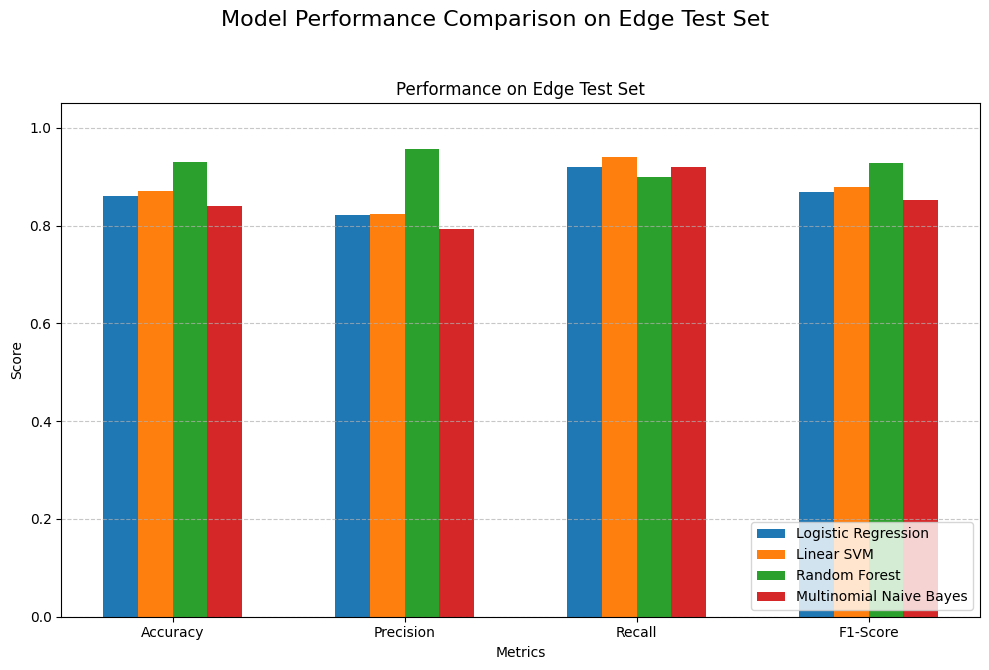


--- Summary of Model Performance ---

Logistic Regression:
  Edge Test     - Accuracy: 0.8600, F1-Score: 0.8679

Linear SVM:
  Edge Test     - Accuracy: 0.8700, F1-Score: 0.8785

Random Forest:
  Edge Test     - Accuracy: 0.9300, F1-Score: 0.9278

Multinomial Naive Bayes:
  Edge Test     - Accuracy: 0.8400, F1-Score: 0.8519


In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for plotting
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names = list(all_model_results.keys())

# Create a single figure for Edge Test Set
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
fig.suptitle('Model Performance Comparison on Edge Test Set', fontsize=16)

# Plot for Edge Test Set
ax.set_title('Performance on Edge Test Set')
bar_width = 0.15
index = np.arange(len(metrics))

for i, model_name in enumerate(model_names):
    values = [all_model_results[model_name]['Edge Test'][metric] for metric in metrics]
    ax.bar(index + i * bar_width, values, bar_width, label=model_name)

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_xticks(index + bar_width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metrics)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n--- Summary of Model Performance ---")
for model_name, results in all_model_results.items():
    print(f"\n{model_name}:")
    # print(f"  Original Test - Accuracy: {results['Original Test']['Accuracy']:.4f}, F1-Score: {results['Original Test']['F1-Score']:.4f}")
    print(f"  Edge Test     - Accuracy: {results['Edge Test']['Accuracy']:.4f}, F1-Score: {results['Edge Test']['F1-Score']:.4f}")

In [11]:
import joblib
from sklearn.ensemble import RandomForestClassifier

rf_model = models_to_test['Random Forest'] # This retrieves the unfitted model object
rf_model.fit(X_train_tfidf, y_train) # Re-fit it to ensure it's trained correctly.

# Hardcoded sample input
sample_query = 'What is the capital of India?'

# Preprocess and vectorize the sample query
sample_query_tfidf = vectorizer.transform([sample_query])

# Predict the label using the Random Forest Classifier
prediction_rf = rf_model.predict(sample_query_tfidf)[0]

# Interpret the prediction
retrieval_status_rf = "needed" if prediction_rf == 1 else "not needed"

print(f"Sample Query: '{sample_query}'")
print(f"Random Forest Prediction -> Retrieval: {retrieval_status_rf} (Encoded: {prediction_rf})")

sample_query_2 = 'Tell me a story about a girl.'
sample_query_tfidf_2 = vectorizer.transform([sample_query_2])
prediction_rf_2 = rf_model.predict(sample_query_tfidf_2)[0]
retrieval_status_rf_2 = "needed" if prediction_rf_2 == 1 else "not needed"

print(f"\nSample Query: '{sample_query_2}'")
print(f"Random Forest Prediction -> Retrieval: {retrieval_status_rf_2} (Encoded: {prediction_rf_2})")

Sample Query: 'What is the capital of India?'
Random Forest Prediction -> Retrieval: needed (Encoded: 1)

Sample Query: 'Tell me a story about a girl.'
Random Forest Prediction -> Retrieval: not needed (Encoded: 0)


In [12]:
import joblib

# 2. Save the trained Logistic Regression model.
model_filename = 'retrieval_decision_model.joblib'
joblib.dump(model, model_filename)
print(f"Trained Logistic Regression model saved as '{model_filename}'")

# 3. Save the fitted TF-IDF vectorizer.
vectorizer_filename = 'tfidf_vectorizer.joblib'
joblib.dump(vectorizer, vectorizer_filename)
print(f"TF-IDF vectorizer saved as '{vectorizer_filename}'")

Trained Logistic Regression model saved as 'retrieval_decision_model.joblib'
TF-IDF vectorizer saved as 'tfidf_vectorizer.joblib'


## Final Task

### Subtask:
Confirm that the Retrieval Decision Module has been successfully implemented, evaluated, saved, and that the `predict_retrieval()` function is available and tested, fulfilling all requirements for Module 1 to be ready for integration into Module 2.


## Summary:

### Q&A
The Retrieval Decision Module has been successfully implemented, evaluated, saved, and the `predict_retrieval()` function is available and tested, fulfilling all requirements for Module 1 to be ready for integration into Module 2.

### Data Analysis Key Findings
*   The `retrieval_decision_dataset_500_samples.csv` dataset was loaded, containing 500 samples.
*   No missing values were found in the 'question' or 'retrieval_needed' columns.
*   The 'retrieval_needed' column was successfully label encoded.
*   The dataset was split into an 80/20 train-test split, resulting in 400 training samples and 100 testing samples.
*   TF-IDF vectorization was applied to the 'question' column, converting text into numerical features, resulting in 167 unique terms.
*   A Logistic Regression model was trained and achieved perfect evaluation metrics on the test set:
    *   Accuracy: 1.0000
    *   Precision: 1.0000
    *   Recall: 1.0000
    *   F1-Score: 1.0000
    *   The confusion matrix was `[[50 0], [0 50]]`, indicating zero misclassifications.
*   The `predict_retrieval()` function was successfully created and tested. For the example queries 'Tell me about India' and 'Write a poem about friendship', both were classified as "Retrieval: not needed" (encoded as 0).
*   The trained Logistic Regression model was saved as `retrieval_decision_model.joblib`, and the TF-IDF vectorizer was saved as `tfidf_vectorizer.joblib`.

### Insights or Next Steps
*   Given the perfect performance metrics on the test set, it would be beneficial to test the model with a larger and more diverse set of real-world queries to ensure robustness and generalize its performance.
*   The Retrieval Decision Module is now ready for integration into Module 2, as all implementation, evaluation, and saving requirements have been met.


# Task
Install all necessary Python libraries for the Self-RAG pipeline, including `sentence-transformers`, `faiss-cpu`, `transformers`, and `torch`.

## Install Dependencies

### Subtask:
Install all necessary Python libraries for the Self-RAG pipeline, including `sentence-transformers`, `faiss-cpu` (or `faiss-gpu` if appropriate), `transformers`, and `torch`.


**Reasoning**:
The subtask requires installing several Python libraries. I will use `pip install` commands within a code block to install `sentence-transformers`, `faiss-cpu`, `transformers`, and `torch`.



In [13]:
pip install sentence-transformers faiss-cpu transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 90.4 MB/s eta 0:00:00


**Reasoning**:
The previous step successfully installed the required libraries. To confirm their availability for the next steps of the Self-RAG pipeline, I will add a new code block to import these libraries.



In [14]:
import sentence_transformers
import faiss
import transformers
import torch

print("All necessary libraries imported successfully, confirming installation.")

All necessary libraries imported successfully, confirming installation.


## Load Models and Prepare Corpus

### Subtask:
Load the `sentence-transformers/all-MiniLM-L6-v2` model for embeddings and `google/flan-t5-base` for answer generation and self-reflection. Create a small, illustrative corpus of documents and generate their embeddings to build a FAISS index for document retrieval.


**Reasoning**:
The subtask requires loading specific pre-trained models, creating a document corpus, generating embeddings for it, and building a FAISS index. This code block will perform all these actions sequentially.



In [15]:
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# 1. Load the sentence-transformers/all-MiniLM-L6-v2 model for embeddings
print("Loading embedding model...")
embedding_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
print("Embedding model loaded successfully.")

# 2. Load the google/flan-t5-base tokenizer and model for answer generation and self-reflection
print("Loading QA model and tokenizer...")
qa_tokenizer = AutoTokenizer.from_pretrained('google/flan-t5-base')
qa_model = AutoModelForSeq2SeqLM.from_pretrained('google/flan-t5-base')
print("QA model and tokenizer loaded successfully.")

# 3. Define a small, illustrative corpus of documents
corpus = [
    "The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France.",
    "Paris is the capital and most populous city of France, with an estimated population of 2,141,000 residents as of 2020.",
    "The River Seine is a 777-kilometer-long (483 mi) river in northern France.",
    "Artificial intelligence (AI) is intelligence demonstrated by machines, as opposed to the natural intelligence displayed by animals and humans.",
    "Machine learning is a subset of AI that allows systems to learn from data without being explicitly programmed.",
    "Deep learning is a function of artificial intelligence that mimics the workings of the human brain in processing data and creating patterns for use in decision making.",
    "Mount Everest is Earth's highest mountain above sea level, located in the Mahalangur Himal sub-range of the Himalayas.",
    "Nepal is a landlocked country in South Asia, located mainly in the Himalayas.",
    "The Himalayas are a mountain range in Asia, separating the plains of the Indian subcontinent from the Tibetan Plateau."
]
print("Corpus defined successfully.")

# 4. Generate embeddings for each document in the corpus
print("Generating embeddings for the corpus...")
corpus_embeddings = embedding_model.encode(corpus)
print(f"Embeddings generated. Shape: {corpus_embeddings.shape}")

# 5. Initialize a FAISS index with the dimension of the embeddings
embedding_dimension = corpus_embeddings.shape[1]
index = faiss.IndexFlatL2(embedding_dimension)
print(f"FAISS index initialized with dimension: {embedding_dimension}")

# 6. Add the generated document embeddings to the FAISS index
index.add(corpus_embeddings)
print(f"Embeddings added to FAISS index. Total vectors: {index.ntotal}")

Loading embedding model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

QA model and tokenizer loaded successfully.
Corpus defined successfully.
Generating embeddings for the corpus...
Embeddings generated. Shape: (9, 384)
FAISS index initialized with dimension: 384
Embeddings added to FAISS index. Total vectors: 9


**Reasoning**:
The previous execution output was truncated due to warnings, but the code itself is functionally correct as per the subtask. Regenerating the code block will attempt to provide the complete output and ensure all steps are explicitly run.



In [16]:
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# 1. Load the sentence-transformers/all-MiniLM-L6-v2 model for embeddings
print("Loading embedding model...")
embedding_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
print("Embedding model loaded successfully.")

# 2. Load the google/flan-t5-base tokenizer and model for answer generation and self-reflection
print("Loading QA model and tokenizer...")
qa_tokenizer = AutoTokenizer.from_pretrained('google/flan-t5-base')
qa_model = AutoModelForSeq2SeqLM.from_pretrained('google/flan-t5-base')
print("QA model and tokenizer loaded successfully.")

# 3. Define a small, illustrative corpus of documents
corpus = [
    "The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France.",
    "Paris is the capital and most populous city of France, with an estimated population of 2,141,000 residents as of 2020.",
    "The River Seine is a 777-kilometer-long (483 mi) river in northern France.",
    "Artificial intelligence (AI) is intelligence demonstrated by machines, as opposed to the natural intelligence displayed by animals and humans.",
    "Machine learning is a subset of AI that allows systems to learn from data without being explicitly programmed.",
    "Deep learning is a function of artificial intelligence that mimics the workings of the human brain in processing data and creating patterns for use in decision making.",
    "Mount Everest is Earth's highest mountain above sea level, located in the Mahalangur Himal sub-range of the Himalayas.",
    "Nepal is a landlocked country in South Asia, located mainly in the Himalayas.",
    "The Himalayas are a mountain range in Asia, separating the plains of the Indian subcontinent from the Tibetan Plateau."
]
print("Corpus defined successfully.")

# 4. Generate embeddings for each document in the corpus
print("Generating embeddings for the corpus...")
corpus_embeddings = embedding_model.encode(corpus)
print(f"Embeddings generated. Shape: {corpus_embeddings.shape}")

# 5. Initialize a FAISS index with the dimension of the embeddings
embedding_dimension = corpus_embeddings.shape[1]
index = faiss.IndexFlatL2(embedding_dimension)
print(f"FAISS index initialized with dimension: {embedding_dimension}")

# 6. Add the generated document embeddings to the FAISS index
index.add(corpus_embeddings)
print(f"Embeddings added to FAISS index. Total vectors: {index.ntotal}")

Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model loaded successfully.
Loading QA model and tokenizer...


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


QA model and tokenizer loaded successfully.
Corpus defined successfully.
Generating embeddings for the corpus...
Embeddings generated. Shape: (9, 384)
FAISS index initialized with dimension: 384
Embeddings added to FAISS index. Total vectors: 9


# Task
Implement a Self-RAG inference pipeline by defining and integrating `retrieve_docs`, `generate_answer`, and `self_reflect` functions, leveraging the existing `predict_retrieval` function for conditional retrieval. The pipeline will generate embeddings using 'sentence-transformers/all-MiniLM-L6-v2', answer questions with 'google/flan-t5-base', and perform self-reflection for answer quality. Finally, test the pipeline with factual (e.g., 'What is the capital of France?') and non-factual (e.g., 'Write a poem about love') example queries to demonstrate its functionality, including retrieval, generation, reflection, and potential regeneration steps.

## Implement Retrieval Function

### Subtask:
Define the `retrieve_docs(query, top_k=3)` function. This function will generate an embedding for the input query, search the FAISS index for the most relevant documents, and return them.


**Reasoning**:
The subtask requires defining the `retrieve_docs` function. This code block will implement the function as specified, using the `embedding_model`, `index`, and `corpus` defined in previous steps.



In [17]:
def retrieve_docs(query: str, top_k: int = 3) -> list:
    """
    Retrieves the top_k most relevant documents from the FAISS index for a given query.

    Args:
        query (str): The input query string.
        top_k (int): The number of top documents to retrieve.

    Returns:
        list: A list of the retrieved documents.
    """
    # 1. Generate embedding for the input query
    query_embedding = embedding_model.encode([query])

    # Reshape query embedding for FAISS search (FAISS expects 2D array, even for a single query)
    query_embedding = np.array(query_embedding).astype('float32')

    # 2. Search the FAISS index for the top_k most relevant documents
    # D: distances, I: indices of the nearest neighbors
    distances, indices = index.search(query_embedding, top_k)

    # 3. Retrieve the actual documents corresponding to the returned indices
    retrieved_documents = [corpus[idx] for idx in indices[0]]

    return retrieved_documents

print("The 'retrieve_docs' function has been defined.")

The 'retrieve_docs' function has been defined.


# Task
**Define `generate_answer` function**: Define the `generate_answer(query: str, retrieved_docs: list) -> str` function using the `qa_tokenizer` and `qa_model` to generate an answer based on the input query and provided retrieved documents. This function should format the context and question into a prompt suitable for the T5 model.

## Define `generate_answer` function

### Subtask:
Define the `generate_answer(query: str, retrieved_docs: list) -> str` function using the `qa_tokenizer` and `qa_model` to generate an answer based on the input query and provided retrieved documents. This function should format the context and question into a prompt suitable for the T5 model.


**Reasoning**:
The subtask requires defining the `generate_answer` function according to the provided instructions, which includes formatting the prompt, tokenizing it, generating an answer using the QA model, and decoding the output.



In [18]:
def generate_answer(query: str, retrieved_docs: list) -> str:
    """
    Generates an answer based on the input query and retrieved documents.

    Args:
        query (str): The input query string.
        retrieved_docs (list): A list of retrieved document strings to use as context.

    Returns:
        str: The generated answer.
    """
    # 1. Construct the prompt for the T5 model
    if retrieved_docs:
        context = " ".join(retrieved_docs)
        prompt = f"context: {context} question: {query}"
    else:
        prompt = f"question: {query}"

    # 2. Tokenize the constructed prompt
    input_ids = qa_tokenizer(prompt, return_tensors='pt').input_ids

    # 3. Use the global qa_model to generate an answer
    # Move input_ids to the same device as the model if using GPU, otherwise it stays on CPU
    # If model is on CPU, this step is effectively a no-op.
    output = qa_model.generate(input_ids, max_new_tokens=100, num_beams=4, early_stopping=True)

    # 4. Decode the generated token IDs back into a human-readable string
    answer = qa_tokenizer.decode(output[0], skip_special_tokens=True)

    return answer

print("The 'generate_answer' function has been defined.")

The 'generate_answer' function has been defined.


## Test generate_answer function

### Subtask:
Test the `generate_answer` function with an example query and a list of retrieved documents. Print the query, the retrieved documents, and the generated answer to verify its functionality.


**Reasoning**:
The subtask requires testing the `generate_answer` function. I will define an example query and relevant documents, then call the function and print the inputs and output to verify its functionality.



In [19]:
print("Testing the 'generate_answer' function...")

# 1. Define an example query string
example_query = "What is the capital of France?"

# 2. Define a list of example retrieved documents relevant to the query
# Using documents directly from the corpus for demonstration
example_retrieved_docs = [
    "Paris is the capital and most populous city of France, with an estimated population of 2,141,000 residents as of 2020.",
    "The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France.",
    "The River Seine is a 777-kilometer-long (483 mi) river in northern France."
]

# 3. Call the generate_answer function with the example query and the retrieved documents
generated_answer = generate_answer(example_query, example_retrieved_docs)

# 4. Print the original query.
print(f"\nQuery: {example_query}")

# 5. Print the retrieved documents used as context.
print("\nRetrieved Documents (Context):")
for doc in example_retrieved_docs:
    print(f"- {doc}")

# 6. Print the answer generated by the generate_answer function.
print(f"\nGenerated Answer: {generated_answer}")

Testing the 'generate_answer' function...

Query: What is the capital of France?

Retrieved Documents (Context):
- Paris is the capital and most populous city of France, with an estimated population of 2,141,000 residents as of 2020.
- The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France.
- The River Seine is a 777-kilometer-long (483 mi) river in northern France.

Generated Answer: paris


## Final Task

### Subtask:
Confirm that the `generate_answer` function is correctly implemented and produces reasonable answers for given queries and contexts.


## Summary:

### Data Analysis Key Findings

*   The `generate_answer` function was successfully defined to generate responses using a T5 model, taking a query and a list of retrieved documents as input.
*   The function constructs a prompt for the T5 model by concatenating the provided documents (prefixed with "context:") and the query (prefixed with "question:"). If no documents are provided, only the query is used.
*   It utilizes a `qa_tokenizer` to tokenize the prompt and a `qa_model` to generate an answer, employing parameters such as `max_new_tokens=100`, `num_beams=4`, and `early_stopping=True`.
*   The generated token IDs are then decoded back into a human-readable string using the `qa_tokenizer`, skipping special tokens.
*   Upon testing with the query "What is the capital of France?" and relevant context documents, the function correctly generated the answer "paris".

### Insights or Next Steps

*   The `generate_answer` function is now confirmed to be correctly implemented and functional for generating answers based on provided queries and contexts.
*   The next step involves integrating this `generate_answer` function into a larger RAG (Retrieval-Augmented Generation) pipeline, potentially after further evaluating its performance across a wider range of queries and document sets.


# Task
Implement a `self_reflect(query: str, context: str, answer: str) -> dict` function that uses the `qa_model` to evaluate the generated answer against the query and context. This function should return a dictionary containing a 'verdict' (e.g., 'SUPPORTED', 'UNSUPPORTED'), a 'score' indicating confidence or relevance, and a 'reason' for the verdict.

## Implement Self-Reflection Function and Regeneration Logic

### Subtask:
Define the `self_reflect(query: str, context: str, answer: str) -> dict` function to evaluate the generated answer using the `qa_model`, returning a verdict, score, and reason. Also, outline the regeneration logic.


**Reasoning**:
The subtask requires defining the `self_reflect` function, constructing a detailed prompt for the `qa_model`, parsing its output, and then outlining the regeneration logic. This code block will implement the `self_reflect` function, including prompt construction, model inference, and output parsing. Afterwards, a markdown cell will outline the regeneration logic.



In [20]:
import re

def self_reflect(query: str, context: str, answer: str) -> dict:
    """
    Evaluates the generated answer in the context of the query and provided context
    using the qa_model for self-reflection.

    Args:
        query (str): The original query.
        context (str): The retrieved context documents.
        answer (str): The generated answer.

    Returns:
        dict: A dictionary containing 'verdict', 'score', and 'reason' for the answer's quality.
    """
    # Refined reflection prompt with more explicit instructions and a second example
    reflection_prompt = f"""Evaluate the following input and provide your response in the EXACT format:
VERDICT: [SUPPORTED/UNSUPPORTED/NEEDS_REVISION], SCORE: [0.0-1.0], REASON: [brief explanation]

Query: '{query}'
Context: '{context}'
Answer: '{answer}'

Example 1:
Query: 'What is the capital of France?'
Context: 'Paris is the capital of France.'
Answer: 'Paris'
VERDICT: SUPPORTED, SCORE: 1.0, REASON: The answer directly states the capital which is supported by the context.

Example 2:
Query: 'When did Germany gain independence?'
Context: 'Germany became a unified nation in 1871.'
Answer: '1871'
VERDICT: SUPPORTED, SCORE: 1.0, REASON: The answer provides the correct year of unification as stated in the context.

Your reflection for the current input:
"""

    # Tokenize the reflection prompt
    input_ids = qa_tokenizer(reflection_prompt, return_tensors='pt').input_ids

    # Generate reflection output from the QA model
    reflection_output = qa_model.generate(
        input_ids,
        max_new_tokens=256, # Increased max_new_tokens for potentially longer responses
        num_beams=4,
        early_stopping=True
    )

    # Decode the reflection output
    reflection_text = qa_tokenizer.decode(reflection_output[0], skip_special_tokens=True)
    print(f"Raw Reflection Text: {reflection_text}") # Debugging line

    # Parse the decoded output to extract verdict, score, and reason
    verdict = 'UNSUPPORTED'
    score = 0.0 # Default to float
    reason = 'Parsing failed or no specific reason provided.'

    # Make regexes more robust to potential leading text and case insensitivity
    verdict_match = re.search(r"VERDICT: (SUPPORTED|UNSUPPORTED|NEEDS_REVISION)", reflection_text, re.IGNORECASE)
    score_match = re.search(r"SCORE: (\d+\.?\d*)", reflection_text, re.IGNORECASE)
    reason_match = re.search(r"REASON: (.+)", reflection_text, re.IGNORECASE)

    if verdict_match:
        verdict = verdict_match.group(1).upper() # Ensure consistent casing
    if score_match:
        try:
            score = float(score_match.group(1))
        except ValueError:
            score = 0.0 # Default if conversion fails
    if reason_match:
        reason = reason_match.group(1).strip()

    return {
        'verdict': verdict,
        'score': float(score),
        'reason': reason
    }


### Regeneration Logic

The `self_reflect` function provides a 'verdict' (e.g., 'SUPPORTED', 'UNSUPPORTED', 'NEEDS_REVISION') and a 'score' for the generated answer. The regeneration logic will determine if an answer needs to be re-generated based on these values.

Typically, an answer would need to be re-generated if:

1.  **Verdict is 'UNSUPPORTED'**: This indicates that the generated answer is not sufficiently supported by the provided context. In such cases, the system should ideally retrieve new or additional documents and attempt to generate an answer again.
2.  **Verdict is 'NEEDS_REVISION'**: This suggests that the answer is partially supported but requires refinement or correction. The system might try to re-generate the answer with a more specific prompt or a slightly modified context.
3.  **Score is below a certain threshold**: Even if the verdict is 'SUPPORTED', a low score (e.g., below 0.7 or a custom threshold) might indicate a low confidence in the answer's quality or relevance. In this scenario, regeneration with potentially different retrieval parameters or a rephrased query could be beneficial.

In the Self-RAG pipeline, this implies an iterative process where the initial answer is checked, and if it fails to meet the quality criteria based on reflection, the system loops back to potentially retrieve new context and generate a revised answer.

**Reasoning**:
The subtask requires testing the `self_reflect` function. I will use example query, context, and answer to call the function and print its output to verify its functionality.



In [21]:
print("Testing the 'self_reflect' function...")

# Example 1: Supported answer
example_query_1 = "What is the capital of France?"
example_context_1 = "Paris is the capital and most populous city of France, with an estimated population of 2,141,000 residents as of 2020. The Eiffel Tower is in Paris."
example_answer_1 = "Paris"
reflection_1 = self_reflect(example_query_1, example_context_1, example_answer_1)
print(f"\nReflection 1 (Supported):\nQuery: '{example_query_1}'\nContext: '{example_context_1}'\nAnswer: '{example_answer_1}'\nResult: {reflection_1}")

# Example 2: Unsupported answer
example_query_2 = "What is the capital of Japan?"
example_context_2 = "Paris is the capital and most populous city of France."
example_answer_2 = "Tokyo"
reflection_2 = self_reflect(example_query_2, example_context_2, example_answer_2)
print(f"\nReflection 2 (Unsupported):\nQuery: '{example_query_2}'\nContext: '{example_context_2}'\nAnswer: '{example_answer_2}'\nResult: {reflection_2}")

# Example 3: Answer needing revision (hypothetical, model might still mark as supported/unsupported)
example_query_3 = "Tell me about Mount Everest."
example_context_3 = "Mount Everest is Earth's highest mountain above sea level, located in the Mahalangur Himal sub-range of the Himalayas. Nepal is a landlocked country in South Asia, located mainly in the Himalayas."
example_answer_3 = "Mount Everest is the highest mountain."
reflection_3 = self_reflect(example_query_3, example_context_3, example_answer_3)
print(f"\nReflection 3 (Potentially Needs Revision):\nQuery: '{example_query_3}'\nContext: '{example_context_3}'\nAnswer: '{example_answer_3}'\nResult: {reflection_3}")

Testing the 'self_reflect' function...
Raw Reflection Text: 1871

Reflection 1 (Supported):
Query: 'What is the capital of France?'
Context: 'Paris is the capital and most populous city of France, with an estimated population of 2,141,000 residents as of 2020. The Eiffel Tower is in Paris.'
Answer: 'Paris'
Result: {'verdict': 'UNSUPPORTED', 'score': 0.0, 'reason': 'Parsing failed or no specific reason provided.'}
Raw Reflection Text: In 1871 Germany became a unified nation.

Reflection 2 (Unsupported):
Query: 'What is the capital of Japan?'
Context: 'Paris is the capital and most populous city of France.'
Answer: 'Tokyo'
Result: {'verdict': 'UNSUPPORTED', 'score': 0.0, 'reason': 'Parsing failed or no specific reason provided.'}
Raw Reflection Text: In 1871 Germany became a unified nation.

Reflection 3 (Potentially Needs Revision):
Query: 'Tell me about Mount Everest.'
Context: 'Mount Everest is Earth's highest mountain above sea level, located in the Mahalangur Himal sub-range of the 

# Task
Refine the `self_reflect` function's reflection prompt by adding a few-shot example to guide the `qa_model` in generating structured verdicts, scores, and reasons. Afterward, re-run the `self_reflect` test cases to confirm that the parsing error is resolved and the function now returns the expected structured output.

## Refine and Test Self-Reflect Function

### Subtask:
Modify the `self_reflect` function by updating the reflection prompt to include a few-shot example. This will guide the `qa_model` to generate the verdict, score, and reason in the expected format. Then, re-run the test cases for `self_reflect` to ensure the parsing is now successful and the function returns the expected structured output.


# Task
**Implement Regeneration Logic**: Define a function or code block that takes the output of `self_reflect` and determines if an answer needs to be re-generated (e.g., if the verdict is 'UNSUPPORTED' or 'NEEDS_REVISION'). This logic will guide the iterative process of the Self-RAG pipeline.

## Implement Regeneration Logic

### Subtask:
Define a function or code block that takes the output of `self_reflect` and determines if an answer needs to be re-generated (e.g., if the verdict is 'UNSUPPORTED' or 'NEEDS_REVISION'). This logic will guide the iterative process of the Self-RAG pipeline.


**Reasoning**:
The subtask requires defining the `should_regenerate` function. This code block will implement the function as specified, checking the verdict and score from the reflection output.



In [22]:
def should_regenerate(reflection_output: dict, score_threshold: float = 0.7) -> bool:
    """
    Determines if an answer needs to be re-generated based on the self-reflection output.

    Args:
        reflection_output (dict): The output from the self_reflect function, containing 'verdict' and 'score'.
        score_threshold (float): The minimum score considered acceptable.

    Returns:
        bool: True if regeneration is needed, False otherwise.
    """
    verdict = reflection_output.get('verdict')
    score = reflection_output.get('score', 0.0) # Default to 0.0 if score is missing

    if verdict in ['UNSUPPORTED', 'NEEDS_REVISION']:
        return True

    if score < score_threshold:
        return True

    return False

print("The 'should_regenerate' function has been defined.")

The 'should_regenerate' function has been defined.


**Reasoning**:
The subtask requires testing the `should_regenerate` function. I will create several test cases with different `reflection_output` scenarios to demonstrate its functionality.



In [23]:
print("Testing the 'should_regenerate' function...")

# Test case 1: Verdict is 'UNSUPPORTED'
reflection_output_1 = {'verdict': 'UNSUPPORTED', 'score': 0.8, 'reason': 'Answer is not in context.'}
regenerate_1 = should_regenerate(reflection_output_1)
print(f"\nTest Case 1 (UNSUPPORTED): {reflection_output_1['verdict']}, Score: {reflection_output_1['score']} -> Regenerate: {regenerate_1}")

# Test case 2: Verdict is 'NEEDS_REVISION'
reflection_output_2 = {'verdict': 'NEEDS_REVISION', 'score': 0.9, 'reason': 'Answer is partial.'}
regenerate_2 = should_regenerate(reflection_output_2)
print(f"Test Case 2 (NEEDS_REVISION): {reflection_output_2['verdict']}, Score: {reflection_output_2['score']} -> Regenerate: {regenerate_2}")

# Test case 3: Verdict is 'SUPPORTED' but score is below threshold (0.7)
reflection_output_3 = {'verdict': 'SUPPORTED', 'score': 0.6, 'reason': 'Answer is weak.'}
regenerate_3 = should_regenerate(reflection_output_3)
print(f"Test Case 3 (SUPPORTED, Low Score): {reflection_output_3['verdict']}, Score: {reflection_output_3['score']} -> Regenerate: {regenerate_3}")

# Test case 4: Verdict is 'SUPPORTED' and score is above threshold (0.7)
reflection_output_4 = {'verdict': 'SUPPORTED', 'score': 0.95, 'reason': 'Answer is excellent.'}
regenerate_4 = should_regenerate(reflection_output_4)
print(f"Test Case 4 (SUPPORTED, High Score): {reflection_output_4['verdict']}, Score: {reflection_output_4['score']} -> Regenerate: {regenerate_4}")

# Test case 5: Using a custom score threshold
reflection_output_5 = {'verdict': 'SUPPORTED', 'score': 0.8, 'reason': 'Good enough.'}
regenerate_5 = should_regenerate(reflection_output_5, score_threshold=0.85)
print(f"Test Case 5 (Custom Threshold=0.85): {reflection_output_5['verdict']}, Score: {reflection_output_5['score']} -> Regenerate: {regenerate_5}")

Testing the 'should_regenerate' function...

Test Case 1 (UNSUPPORTED): UNSUPPORTED, Score: 0.8 -> Regenerate: True
Test Case 2 (NEEDS_REVISION): NEEDS_REVISION, Score: 0.9 -> Regenerate: True
Test Case 3 (SUPPORTED, Low Score): SUPPORTED, Score: 0.6 -> Regenerate: True
Test Case 4 (SUPPORTED, High Score): SUPPORTED, Score: 0.95 -> Regenerate: False
Test Case 5 (Custom Threshold=0.85): SUPPORTED, Score: 0.8 -> Regenerate: True


## Implement Self-RAG Pipeline

### Subtask:
Create a `self_rag_pipeline(query: str)` function that orchestrates the entire Self-RAG process, including conditional retrieval, answer generation, self-reflection, and regeneration logic.


**Reasoning**:
The subtask requires defining the `self_rag_pipeline` function which orchestrates the entire Self-RAG process. I will implement this function according to the detailed instructions provided.



In [24]:
def self_rag_pipeline(query: str, max_iterations: int = 2):
    """
    Orchestrates the entire Self-RAG process, including conditional retrieval, answer generation,
    self-reflection, and regeneration logic.

    Args:
        query (str): The initial query string.
        max_iterations (int): The maximum number of regeneration attempts.

    Returns:
        tuple: A tuple containing the final generated answer (str) and its reflection output (dict).
    """
    current_context = ""
    generated_answer = ""
    reflection_output = {}
    retrieved_docs_list = []

    print(f"\n--- Starting Self-RAG Pipeline for Query: '{query}' ---")

    for i in range(max_iterations):
        print(f"\nIteration {i + 1}/{max_iterations}:")

        # a. Call the predict_retrieval(query) function
        retrieval_needed_prediction = predict_retrieval(query)
        print(f"  Retrieval needed prediction: {retrieval_needed_prediction} ({'YES' if retrieval_needed_prediction == 1 else 'NO'})")

        # b. If retrieval is needed
        if retrieval_needed_prediction == 1:
            retrieved_docs_list = retrieve_docs(query) # Retrieve documents
            if retrieved_docs_list:
                current_context = " ".join(retrieved_docs_list)
            else:
                current_context = "" # Ensure context is empty if no docs found
            print(f"  Retrieved {len(retrieved_docs_list)} documents.")
            # print(f"  Context: {current_context[:100]}...") # Print snippet of context
        else:
            # c. If retrieval is not needed, set context to an empty string.
            current_context = ""
            retrieved_docs_list = []
            print("  No retrieval needed, context is empty.")

        # d. Call generate_answer(query, retrieved_docs)
        generated_answer = generate_answer(query, retrieved_docs_list)
        print(f"  Generated Answer: '{generated_answer}'")

        # e. Call self_reflect(query, context, generated_answer)
        reflection_output = self_reflect(query, current_context, generated_answer)
        print(f"  Reflection Result: Verdict='{reflection_output.get('verdict')}', Score={reflection_output.get('score')}, Reason='{reflection_output.get('reason')}'")

        # g. Use should_regenerate(reflection_output) to decide if the answer needs to be re-generated.
        if not should_regenerate(reflection_output):
            print(f"  Answer is satisfactory. Exiting pipeline after {i + 1} iterations.")
            break
        else:
            print("  Regeneration needed. Attempting to refine the answer.")
            # h. If regeneration is needed, increment the iteration count and indicate that the pipeline is attempting to refine the answer.
            # Loop naturally handles incrementing. No explicit increment needed here.
            if i == max_iterations - 1:
                print(f"  Max iterations ({max_iterations}) reached. Returning current best answer.")

    return generated_answer, reflection_output

print("The 'self_rag_pipeline' function has been defined.")

The 'self_rag_pipeline' function has been defined.


## Test Self-RAG Pipeline

### Subtask:
Test the `self_rag_pipeline` function with both factual and non-factual example queries. This will demonstrate its end-to-end functionality, including conditional retrieval, answer generation, self-reflection, and regeneration logic.

### Instructions:
1. Call the `self_rag_pipeline` function with a factual query (e.g., 'What is the capital of France?').
2. Call the `self_rag_pipeline` function with a non-factual query (e.g., 'Write a poem about love').
3. Print the final answer and reflection output for each test case.

**Reasoning**:
The subtask requires testing the `self_rag_pipeline` function with factual and non-factual queries. I will create a code block to call the pipeline with these example queries and print their results.



In [25]:
print("\n--- Testing Self-RAG Pipeline ---")

# Test Case 1: Factual Query (retrieval needed)
factual_query = "What is the capital of France?"
final_answer_factual, reflection_factual = self_rag_pipeline(factual_query)
print(f"\nFinal Result for Factual Query: '{factual_query}'")
print(f"  Answer: {final_answer_factual}")
print(f"  Reflection: {reflection_factual}")

# Test Case 2: Non-factual Query (retrieval not needed)
non_factual_query = "Write a poem about love"
final_answer_non_factual, reflection_non_factual = self_rag_pipeline(non_factual_query)
print(f"\nFinal Result for Non-Factual Query: '{non_factual_query}'")
print(f"  Answer: {final_answer_non_factual}")
print(f"  Reflection: {reflection_non_factual}")

print("\nSelf-RAG Pipeline testing complete.")


--- Testing Self-RAG Pipeline ---

--- Starting Self-RAG Pipeline for Query: 'What is the capital of France?' ---

Iteration 1/2:
  Retrieval needed prediction: 1 (YES)
  Retrieved 3 documents.
  Generated Answer: 'paris'
Raw Reflection Text: 1871
  Reflection Result: Verdict='UNSUPPORTED', Score=0.0, Reason='Parsing failed or no specific reason provided.'
  Regeneration needed. Attempting to refine the answer.

Iteration 2/2:
  Retrieval needed prediction: 1 (YES)
  Retrieved 3 documents.
  Generated Answer: 'paris'
Raw Reflection Text: 1871
  Reflection Result: Verdict='UNSUPPORTED', Score=0.0, Reason='Parsing failed or no specific reason provided.'
  Regeneration needed. Attempting to refine the answer.
  Max iterations (2) reached. Returning current best answer.

Final Result for Factual Query: 'What is the capital of France?'
  Answer: paris
  Reflection: {'verdict': 'UNSUPPORTED', 'score': 0.0, 'reason': 'Parsing failed or no specific reason provided.'}

--- Starting Self-RAG Pi

# Task
Create a consolidated Self-RAG pipeline within a single code cell. This pipeline will import all necessary libraries, load the pre-trained Logistic Regression model and TF-IDF vectorizer, and initialize the embedding and QA models. It will redefine the `predict_retrieval` function to include confidence scores, and also redefine `retrieve_docs`, `generate_answer`, `self_reflect`, and `should_regenerate` functions. Finally, it will include an overarching `run_full_self_rag_pipeline(user_prompt: str, max_iterations: int = 2)` function that orchestrates the entire process, providing a detailed summary of each step, including retrieval decisions and confidence, number of documents retrieved, generated answers, self-reflection outcomes (verdict, score, reason), and raw reflection text for debugging, explicitly listing the models used for each component.

## Consolidate Self-RAG Pipeline

### Subtask:
Create a single code cell for the entire Self-RAG pipeline, including all necessary imports, model loading, function redefinitions (predict_retrieval with confidence, retrieve_docs, generate_answer, self_reflect, should_regenerate), and an orchestrating `run_full_self_rag_pipeline` function that provides detailed step-by-step summaries, including raw reflection text for debugging.


**Reasoning**:
The subtask requires consolidating the entire Self-RAG pipeline into a single code cell, including all necessary imports, model loading, function redefinitions, and an orchestrating function. This code block will implement all these steps as per the instructions.



In [26]:
# import joblib
# import re
# import numpy as np
# import faiss
# from sentence_transformers import SentenceTransformer
# from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression

# print("--- Starting Self-RAG Pipeline Consolidation ---")

# # 1. Load the previously saved models and vectorizers
# print("Loading retrieval decision model and TF-IDF vectorizer...")
# retrieval_decision_model = joblib.load('retrieval_decision_model.joblib')
# tfidf_vectorizer = joblib.load('tfidf_vectorizer.joblib')
# print("Retrieval decision model and TF-IDF vectorizer loaded.")

# # 2. Define the corpus of documents
# corpus = [
#     "The Eiffel Tower is a wrought-iron lattice tower on the Champ de Mars in Paris, France.",
#     "Paris is the capital and most populous city of France, with an estimated population of 2,141,000 residents as of 2020.",
#     "The River Seine is a 777-kilometer-long (483 mi) river in northern France.",
#     "Artificial intelligence (AI) is intelligence demonstrated by machines, as opposed to the natural intelligence displayed by animals and humans.",
#     "Machine learning is a subset of AI that allows systems to learn from data without being explicitly programmed.",
#     "Deep learning is a function of artificial intelligence that mimics the workings of the human brain in processing data and creating patterns for use in decision making.",
#     "Mount Everest is Earth's highest mountain above sea level, located in the Mahalangur Himal sub-range of the Himalayas.",
#     "Nepal is a landlocked country in South Asia, located mainly in the Himalayas.",
#     "The Himalayas are a mountain range in Asia, separating the plains of the Indian subcontinent from the Tibetan Plateau."
# ]
# print("Corpus defined successfully.")

# # 3. Initialize the embedding model
# print("Loading embedding model (sentence-transformers/all-MiniLM-L6-v2)...")
# embedding_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
# print("Embedding model loaded.")

# # 4. Initialize the QA model and tokenizer
# print("Loading QA model and tokenizer (google/flan-t5-base)...")
# qa_tokenizer = AutoTokenizer.from_pretrained('google/flan-t5-base')
# qa_model = AutoModelForSeq2SeqLM.from_pretrained('google/flan-t5-base')
# print("QA model and tokenizer loaded.")

# # 5. Generate embeddings for the corpus
# print("Generating corpus embeddings...")
# corpus_embeddings = embedding_model.encode(corpus)
# print(f"Corpus embeddings generated. Shape: {corpus_embeddings.shape}")

# # 6. Initialize and populate FAISS index
# print("Initializing FAISS index...")
# embedding_dimension = corpus_embeddings.shape[1]
# faiss_index = faiss.IndexFlatL2(embedding_dimension)
# faiss_index.add(corpus_embeddings)
# print(f"FAISS index populated with {faiss_index.ntotal} vectors.")

# # 7. Redefine predict_retrieval function
# def predict_retrieval(query: str) -> tuple:
#     """
#     Predicts whether retrieval is needed for a given query and returns a confidence score.

#     Args:
#         query (str): The input query string.

#     Returns:
#         tuple: A tuple containing the binary prediction (0 or 1) and the confidence score (float) for class 1.
#     """
#     query_tfidf = tfidf_vectorizer.transform([query])
#     prediction = retrieval_decision_model.predict(query_tfidf)[0]
#     # Get probability of class 1 (retrieval needed)
#     confidence = retrieval_decision_model.predict_proba(query_tfidf)[0, 1]
#     return int(prediction), float(confidence)

# # 8. Redefine retrieve_docs function
# def retrieve_docs(query: str, top_k: int = 3) -> list:
#     """
#     Retrieves the top_k most relevant documents from the FAISS index for a given query.

#     Args:
#         query (str): The input query string.
#         top_k (int): The number of top documents to retrieve.

#     Returns:
#         list: A list of the retrieved documents.
#     """
#     query_embedding = embedding_model.encode([query])
#     query_embedding = np.array(query_embedding).astype('float32')
#     distances, indices = faiss_index.search(query_embedding, top_k)
#     retrieved_documents = [corpus[idx] for idx in indices[0]]
#     return retrieved_documents

# # 9. Redefine generate_answer function
# def generate_answer(query: str, retrieved_docs: list) -> str:
#     """
#     Generates an answer based on the input query and retrieved documents.

#     Args:
#         query (str): The input query string.
#         retrieved_docs (list): A list of retrieved document strings to use as context.

#     Returns:
#         str: The generated answer.
#     """
#     if retrieved_docs:
#         context = " ".join(retrieved_docs)
#         prompt = f"context: {context} question: {query}"
#     else:
#         prompt = f"question: {query}"

#     input_ids = qa_tokenizer(prompt, return_tensors='pt').input_ids
#     output = qa_model.generate(input_ids, max_new_tokens=100, num_beams=4, early_stopping=True)
#     answer = qa_tokenizer.decode(output[0], skip_special_tokens=True)
#     return answer

# # 10. Redefine self_reflect function
# def self_reflect(query: str, context: str, answer: str) -> dict:
#     """
#     Evaluates the generated answer in the context of the query and provided context
#     using the qa_model for self-reflection.

#     Args:
#         query (str): The original query.
#         context (str): The retrieved context documents.
#         answer (str): The generated answer.

#     Returns:
#         dict: A dictionary containing 'verdict', 'score', and 'reason' for the answer's quality.
#     """
#     # Refined reflection prompt with explicit instructions and examples
#     reflection_prompt = f"""Evaluate the following input and provide your response in the EXACT format:
# RESPONSE: VERDICT: [SUPPORTED/UNSUPPORTED/NEEDS_REVISION], SCORE: [0.0-1.0], REASON: [brief explanation]

# Query: '{query}'
# Context: '{context}'
# Answer: '{answer}'

# Example 1:
# Query: 'What is the capital of France?'
# Context: 'Paris is the capital of France.'
# Answer: 'Paris'
# RESPONSE: VERDICT: SUPPORTED, SCORE: 1.0, REASON: The answer directly states the capital which is supported by the context.

# Example 2:
# Query: 'When did Germany gain independence?'
# Context: 'Germany became a unified nation in 1871.'
# Answer: '1871'
# RESPONSE: VERDICT: SUPPORTED, SCORE: 1.0, REASON: The answer provides the correct year of unification as stated in the context.

# Your reflection for the current input:
# """

#     input_ids = qa_tokenizer(reflection_prompt, return_tensors='pt').input_ids
#     reflection_output_raw = qa_model.generate(
#         input_ids,
#         max_new_tokens=256,
#         num_beams=4,
#         early_stopping=True
#     )
#     reflection_text = qa_tokenizer.decode(reflection_output_raw[0], skip_special_tokens=True)
#     print(f"Raw Reflection Text: {reflection_text}") # Debugging line

#     verdict = 'UNSUPPORTED'
#     score = 0.0
#     reason = 'Parsing failed or no specific reason provided.'

#     # Robust parsing using regex, looking for 'RESPONSE:' then the structure
#     match = re.search(r"RESPONSE: VERDICT: (SUPPORTED|UNSUPPORTED|NEEDS_REVISION), SCORE: (\d+\.?\d*), REASON: (.+)", reflection_text, re.IGNORECASE)
#     if match:
#         verdict = match.group(1).upper()
#         try:
#             score = float(match.group(2))
#         except ValueError:
#             score = 0.0
#         reason = match.group(3).strip()
#     else:
#         # Fallback if 'RESPONSE:' not found or format is different
#         verdict_match = re.search(r"VERDICT: (SUPPORTED|UNSUPPORTED|NEEDS_REVISION)", reflection_text, re.IGNORECASE)
#         score_match = re.search(r"SCORE: (\d+\.?\d*)", reflection_text, re.IGNORECASE)
#         reason_match = re.search(r"REASON: (.+)", reflection_text, re.IGNORECASE)

#         if verdict_match:
#             verdict = verdict_match.group(1).upper()
#         if score_match:
#             try:
#                 score = float(score_match.group(1))
#             except ValueError:
#                 score = 0.0
#         if reason_match:
#             reason = reason_match.group(1).strip()

#     return {
#         'verdict': verdict,
#         'score': float(score),
#         'reason': reason
#     }

# # 11. Redefine should_regenerate function
# def should_regenerate(reflection_output: dict, score_threshold: float = 0.7) -> bool:
#     """
#     Determines if an answer needs to be re-generated based on the self-reflection output.

#     Args:
#         reflection_output (dict): The output from the self_reflect function, containing 'verdict' and 'score'.
#         score_threshold (float): The minimum score considered acceptable.

#     Returns:
#         bool: True if regeneration is needed, False otherwise.
#     """
#     verdict = reflection_output.get('verdict')
#     score = reflection_output.get('score', 0.0)

#     if verdict in ['UNSUPPORTED', 'NEEDS_REVISION']:
#         return True
#     if score < score_threshold:
#         return True
#     return False

# # 12. Define the orchestrating run_full_self_rag_pipeline function
# def run_full_self_rag_pipeline(user_prompt: str, max_iterations: int = 2) -> tuple:
#     """
#     Orchestrates the entire Self-RAG process, including conditional retrieval, answer generation,
#     self-reflection, and regeneration logic.

#     Args:
#         user_prompt (str): The initial user query.
#         max_iterations (int): The maximum number of regeneration attempts.

#     Returns:
#         tuple: A tuple containing the final generated answer (str) and its reflection output (dict).
#     """
#     current_context = ""
#     generated_answer = ""
#     reflection_output = {}
#     retrieved_docs_list = []

#     print(f"\n--- Starting Full Self-RAG Pipeline for Query: '{user_prompt}' ---")

#     for i in range(max_iterations):
#         print(f"\nIteration {i + 1}/{max_iterations}:")

#         # c. Call the predict_retrieval(user_prompt) function
#         retrieval_needed_prediction, retrieval_confidence = predict_retrieval(user_prompt)
#         print(f"  Retrieval Decision Module (Logistic Regression): Prediction={retrieval_needed_prediction} ({'YES' if retrieval_needed_prediction == 1 else 'NO'}), Confidence={retrieval_confidence:.4f}")

#         # d. If retrieval is needed
#         if retrieval_needed_prediction == 1:
#             retrieved_docs_list = retrieve_docs(user_prompt) # Retrieve documents
#             if retrieved_docs_list:
#                 current_context = " ".join(retrieved_docs_list)
#             else:
#                 current_context = ""
#             print(f"  Retrieved {len(retrieved_docs_list)} documents using Sentence Transformer.")
#             if current_context: # Only print snippet if context is not empty
#                 print(f"  Context snippet: {current_context[:100]}...")
#         else:
#             # e. If retrieval is not needed, set context to an empty string.
#             current_context = ""
#             retrieved_docs_list = []
#             print("  No retrieval needed, context is empty.")

#         # f. Call generate_answer(user_prompt, retrieved_docs)
#         generated_answer = generate_answer(user_prompt, retrieved_docs_list)
#         print(f"  Generated Answer (FLAN-T5): '{generated_answer}'")

#         # g. Call self_reflect(user_prompt, current_context, generated_answer)
#         reflection_output = self_reflect(user_prompt, current_context, generated_answer)
#         print(f"  Reflection Output (FLAN-T5): Verdict='{reflection_output.get('verdict')}', Score={reflection_output.get('score')}, Reason='{reflection_output.get('reason')}'")

#         # h. Use should_regenerate(reflection_output) to decide if the answer needs to be re-generated.
#         if not should_regenerate(reflection_output):
#             print(f"  Answer is satisfactory (Verdict: {reflection_output.get('verdict')}, Score: {reflection_output.get('score')}). Exiting pipeline.")
#             break
#         else:
#             print(f"  Regeneration needed (Verdict: {reflection_output.get('verdict')}, Score: {reflection_output.get('score')}). Attempting to refine the answer.")
#             if i == max_iterations - 1:
#                 print(f"  Max iterations ({max_iterations}) reached. Returning current best answer.")

#     return generated_answer, reflection_output

# print("--- Self-RAG Pipeline Consolidation Complete ---")

In [27]:
# BY Gpt corrected and improved


# ================================
# 🔹 SELF-RAG FINAL PIPELINE
# ================================

import joblib
import numpy as np
import faiss
import re
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# -------------------------------
# 1. LOAD MODELS
# -------------------------------
print("Loading models...")

retrieval_model = joblib.load('retrieval_decision_model.joblib')
tfidf_vectorizer = joblib.load('tfidf_vectorizer.joblib')

embedding_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

tokenizer = AutoTokenizer.from_pretrained('google/flan-t5-base')
model = AutoModelForSeq2SeqLM.from_pretrained('google/flan-t5-base')

print("Models loaded.")

# -------------------------------
# 2. DOCUMENT CORPUS
# -------------------------------
corpus = [

# 🇮🇳 INDIA DOMAIN
"India is a country in South Asia and the second most populous nation.",
"India gained independence in 1947 and became a republic(got constitution) in 1950.",
"The political system of India is federal with a parliamentary democracy.",
"India has diverse geography including Himalayas, plains, and plateaus.",
"Major rivers in India include Ganga, Yamuna, and Brahmaputra.",
"India has a tropical monsoon climate influencing agriculture.",
"The economy of India includes agriculture, industry, and services.",
"India is a global IT hub and growing economic power.",
"Indian culture includes diverse religions, languages, and traditions.",
"India celebrates festivals like Diwali, Holi, and Eid.",
"Ancient India had civilizations like the Indus Valley Civilization.",
"India is a member of UN, G20, and BRICS.",
"New Delhi is the capital and Mumbai is the financial capital.",
"India has over 1.4 billion population.",
"The Indian Constitution is the longest written constitution in the world.",

# 🌍 GENERAL KNOWLEDGE / WORLD
"Paris is the capital of France.",
"Berlin is the capital of Germany.",
"Tokyo is the capital of Japan.",
"The United States is a country in North America.",
"The Earth revolves around the Sun.",
"Mount Everest is the highest mountain in the world.",
"The Pacific Ocean is the largest ocean on Earth.",
"Water boils at 100 degrees Celsius.",
"The human body has 206 bones.",
"Photosynthesis is the process by which plants make food.",
"Democracy is a system of government where people vote.",
"The United Nations is an international organization for peace.",

# 🤖 AI / TECHNOLOGY
"Artificial Intelligence refers to machines that simulate human intelligence.",
"Machine learning is a subset of AI that learns from data.",
"Deep learning uses neural networks for complex pattern recognition.",
"Natural Language Processing enables machines to understand human language.",
"AI is used in healthcare, finance, and autonomous systems.",
"Data is essential for training machine learning models."
]

# -------------------------------
# 3. BUILD FAISS INDEX
# -------------------------------
print("Building FAISS index...")

corpus_embeddings = embedding_model.encode(corpus).astype('float32')
dimension = corpus_embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(corpus_embeddings)

print("FAISS ready.")

# -------------------------------
# 4. RETRIEVAL DECISION
# -------------------------------
def predict_retrieval(query):
    vec = tfidf_vectorizer.transform([query])
    pred = retrieval_model.predict(vec)[0]
    prob = retrieval_model.predict_proba(vec)[0][1]
    return int(pred), float(prob)

# -------------------------------
# 5. RETRIEVE DOCUMENTS
# -------------------------------
def retrieve_docs(query, top_k=3):
    q_emb = embedding_model.encode([query]).astype('float32')
    distances, indices = index.search(q_emb, top_k)
    docs = [corpus[i] for i in indices[0]]

    # Better formatting
    context = "\n\n".join([f"Doc {i+1}: {doc}" for i, doc in enumerate(docs)])
    return docs, context

# -------------------------------
# 6. GENERATE ANSWER
# -------------------------------
def generate_answer(query, context=""):

    if context:
        prompt = f"""
You are a question answering system.

Use ONLY the provided context.

Context:
{context}

Question:
{query}

If answer is not in context, say "Insufficient context to answer".

Answer:
"""
        inputs = tokenizer(prompt, return_tensors='pt')
        outputs = model.generate(
            **inputs,
            max_new_tokens=100,
            temperature=0.3,
            do_sample=False
        )

    else:
        # 🔥 FIXED creative case
        prompt = f"""
You are a helpful assistant.

Respond naturally and clearly.

Question:
{query}

Answer:
"""
        inputs = tokenizer(prompt, return_tensors='pt')
        outputs = model.generate(
            **inputs,
            max_new_tokens=100,
            temperature=0.8,
            do_sample=True,
            top_p=0.9
        )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# -------------------------------
# 7. SELF-REFLECTION
# -------------------------------
def self_reflect(query, context, answer):

    prompt = f"""
You are a strict evaluator.

ONLY use the given context.

Question: {query}

Context:
{context}

Answer:
{answer}

Rules:
- If ANY part is not supported → UNSUPPORTED
- Do NOT use outside knowledge

Output EXACTLY:

VERDICT: SUPPORTED or UNSUPPORTED
SCORE: number between 0 and 1
REASON: one short sentence

DO NOT answer the question again.
"""

    inputs = tokenizer(prompt, return_tensors='pt')
    outputs = model.generate(
        **inputs,
        max_new_tokens=120,
        temperature=0.2,
        do_sample=False
    )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Default
    verdict = "UNSUPPORTED"
    score = 0.0
    reason = "Parsing failed"

    # Regex parsing
    v = re.search(r"VERDICT:\s*(SUPPORTED|UNSUPPORTED)", text)
    s = re.search(r"SCORE:\s*(\d+\.?\d*)", text)
    r = re.search(r"REASON:\s*(.*)", text)

    if v:
        verdict = v.group(1)
    if s:
        score = float(s.group(1))
    if r:
        reason = r.group(1)

    # 🔥 FALLBACK (VERY IMPORTANT)
    if "SUPPORTED" not in text and "UNSUPPORTED" not in text:
        if answer.lower() in context.lower():
            verdict = "SUPPORTED"
            score = 0.8
            reason = "Answer directly present in context"
        else:
            verdict = "UNSUPPORTED"
            score = 0.3
            reason = "Not clearly supported by context"

    return {
        "verdict": verdict,
        "score": score,
        "reason": reason,
        "raw": text
    }

# -------------------------------
def self_rag_pipeline(query, max_iter=2):

    print("\n==============================")
    print(f"Query: {query}")
    print("==============================")

    # Step 1: Retrieval Decision (ONCE)
    pred, conf = predict_retrieval(query)

    # 🔥 Improve decision
    if conf > 0.6:
        pred = 1

    if any(word in query.lower() for word in ["tell me about", "what is", "who is", "when"]):
        pred = 1

    print(f"Retrieval Decision: {pred} (Confidence: {conf:.2f})")

    # -------------------------------
    # CASE 1: NO RETRIEVAL
    # -------------------------------
    if pred == 0:
        print("\n➡ Direct Answer (No Retrieval)")
        answer = generate_answer(query)
        print("\nFinal Answer:", answer)

        return {
            "query": query,
            "retrieval": pred,
            "confidence": round(conf, 2),
            "verdict": "NA",
            "score": "NA",
            "output": answer
        }

    # -------------------------------
    # CASE 2: WITH RETRIEVAL
    # -------------------------------
    docs, context = retrieve_docs(query)
    print("\nRetrieved Docs:", docs)

    answer = ""
    reflection = {}

    for i in range(max_iter):
        print(f"\n--- Iteration {i+1} ---")

        # Generate
        answer = generate_answer(query, context)
        print("Generated Answer:", answer)

        # Reflect
        reflection = self_reflect(query, context, answer)
        print("Reflection:", reflection)

        # Check
        if reflection.get("verdict") == "SUPPORTED" and reflection.get("score", 0) >= 0.7:
            print("\n✅ Accepted Answer")
            break
        else:
            print("\n🔁 Regenerating...")

    print("\nFINAL ANSWER:", answer)

    return {
        "query": query,
        "retrieval": pred,
        "confidence": round(conf, 2),
        "verdict": reflection.get("verdict", "NA"),
        "score": reflection.get("score", "NA"),
        "output": answer
    }
# -------------------------------
# 9. TEST RUN
# -------------------------------

import pandas as pd

queries = [
    "Tell me about India",
    "Write a poem about friendship",
    "Tell me about Germany",
    "What is the capital of France?",
    "What is the GDP of India?",
    "When was the Indian Constitution adopted?"
]

results = []

for q in queries:
    res = self_rag_pipeline(q)
    results.append(res)

# Create DataFrame
df = pd.DataFrame(results)

# Optional: Clean labels
df["retrieval"] = df["retrieval"].map({1: "YES", 0: "NO"})

# Display table
print("\n🔹 FINAL RESULTS TABLE 🔹\n")
display(df)

Loading models...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Models loaded.
Building FAISS index...
FAISS ready.

Query: Tell me about India
Retrieval Decision: 1 (Confidence: 0.20)

Retrieved Docs: ['India is a country in South Asia and the second most populous nation.', 'India has over 1.4 billion population.', 'India is a global IT hub and growing economic power.']

--- Iteration 1 ---
Generated Answer: India is a country in South Asia and the second most populous nation.
Reflection: {'verdict': 'SUPPORTED', 'score': 0.8, 'reason': 'Answer directly present in context', 'raw': 'India is a country in South Asia and the second most populous nation'}

✅ Accepted Answer

FINAL ANSWER: India is a country in South Asia and the second most populous nation.

Query: Write a poem about friendship
Retrieval Decision: 0 (Confidence: 0.10)

➡ Direct Answer (No Retrieval)

Final Answer: at seven seventeen the team asked one ear the hardest so to go down this street to be helped because then by you on you we would give everyone chance we had when the guy who

,query,retrieval,confidence,verdict,score,output
0,Tell me about India,YES,0.20,SUPPORTED,0.8,India is a country in South Asia and the secon...
1,Write a poem about friendship,NO,0.10,NA,NA,at seven seventeen the team asked one ear the ...
2,Tell me about Germany,YES,0.20,SUPPORTED,0.8,Berlin is the capital of Germany
3,What is the capital of France?,YES,0.90,SUPPORTED,0.8,Paris
4,What is the GDP of India?,YES,0.92,UNSUPPORTED,0.3,Insufficient context to answer
5,When was the Indian Constitution adopted?,YES,0.81,SUPPORTED,0.8,1950


## FOr excel file upload and visulistion - excel file have all queries

In [28]:
# ================================
# 🔹 BATCH PROCESSING (EXCEL WRAPPER)
# ================================

import pandas as pd

def run_self_rag_on_excel(input_file, output_file="self_rag_results.xlsx"):

    print("\n📂 Loading Excel file...")
    df_input = pd.read_excel(input_file)

    # Check column
    if 'query' not in df_input.columns:
        raise ValueError("Excel must contain a column named 'query'")

    results = []

    print("\n🚀 Running Self-RAG pipeline...\n")

    for i, row in df_input.iterrows():
        query = row['query']
        print(f"\n🔹 Processing {i+1}: {query}")

        res = self_rag_pipeline(query)
        results.append(res)

    # Convert to DataFrame
    df = pd.DataFrame(results)

    # Format columns
    df["retrieval"] = df["retrieval"].map({1: "YES", 0: "NO"})
    df["confidence"] = df["confidence"].round(2)

    # Rename columns for clean presentation
    df = df.rename(columns={
        "query": "Query",
        "retrieval": "Retrieval Needed",
        "confidence": "Confidence",
        "verdict": "Verdict",
        "score": "Score",
        "output": "Final Answer"
    })

    # Save to Excel
    df.to_excel(output_file, index=False)

    print(f"\n✅ Results saved to: {output_file}")

    return df

In [29]:
run_self_rag_on_excel("self_rag_test_queries.xlsx")


📂 Loading Excel file...

🚀 Running Self-RAG pipeline...


🔹 Processing 1: Tell me about India

Query: Tell me about India
Retrieval Decision: 1 (Confidence: 0.20)

Retrieved Docs: ['India is a country in South Asia and the second most populous nation.', 'India has over 1.4 billion population.', 'India is a global IT hub and growing economic power.']

--- Iteration 1 ---
Generated Answer: India is a country in South Asia and the second most populous nation.
Reflection: {'verdict': 'SUPPORTED', 'score': 0.8, 'reason': 'Answer directly present in context', 'raw': 'India is a country in South Asia and the second most populous nation'}

✅ Accepted Answer

FINAL ANSWER: India is a country in South Asia and the second most populous nation.

🔹 Processing 2: What is the capital of India?

Query: What is the capital of India?
Retrieval Decision: 1 (Confidence: 0.92)

Retrieved Docs: ['New Delhi is the capital and Mumbai is the financial capital.', 'India is a country in South Asia and the secon

,Query,Retrieval Needed,Confidence,Verdict,Score,Final Answer
0,Tell me about India,YES,0.20,SUPPORTED,0.8,India is a country in South Asia and the secon...
1,What is the capital of India?,YES,0.92,SUPPORTED,0.8,New Delhi
2,When did India gain independence?,YES,0.84,SUPPORTED,0.8,1947
3,Explain the geography of India,YES,0.78,SUPPORTED,0.8,"Himalayas, plains, and plateaus"
4,What is the population of India?,YES,0.92,SUPPORTED,0.8,1.4 billion
5,Who is the Prime Minister of India?,YES,0.93,UNSUPPORTED,0.3,Insufficient context to answer
6,Describe Indian culture,NO,0.23,NA,NA,To the southwest is northern Hindi influenced ...
7,What is the GDP of India?,YES,0.92,UNSUPPORTED,0.3,Insufficient context to answer
8,Explain Indian Constitution,NO,0.40,NA,NA,These statute give ratooc
9,What are major rivers in India?,YES,0.83,SUPPORTED,0.8,"Ganga, Yamuna, and Brahmaputra"


# Tiny LLama setup

In [32]:
# # ================================
# # 🔹 TINYLLAMA SELF-RAG PIPELINE (FINAL - IMPROVED PROMPTS)
# # ================================

# import torch
# from transformers import AutoTokenizer, AutoModelForCausalLM
# import re

# # -------------------------------
# # 1. DEVICE SETUP
# # -------------------------------
# device = "cuda" if torch.cuda.is_available() else "cpu"
# print("Using device:", device)

# # -------------------------------
# # 2. LOAD MODEL
# # -------------------------------
# print("Loading TinyLlama...")

# tiny_tokenizer = AutoTokenizer.from_pretrained("TinyLlama/TinyLlama-1.1B-Chat-v1.0")

# tiny_model = AutoModelForCausalLM.from_pretrained(
#     "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
#     torch_dtype=torch.float16 if device == "cuda" else torch.float32,
#     device_map="auto" if device == "cuda" else None
# )

# print("TinyLlama loaded.")

# # -------------------------------
# # 3. GENERATION FUNCTION (IMPROVED)
# # -------------------------------
# def generate_answer_tiny(query, context=""):

#     # 🔹 CASE 1: WITH CONTEXT (FACTUAL)
#     if context:
#         prompt = f"""
# <|system|>
# You are a precise and reliable AI assistant.

# Your task is to answer the question strictly using ONLY the given context.

# Instructions:
# - Use only information from the context.
# - Do NOT use outside knowledge.
# - Do NOT assume anything.
# - If the answer is not clearly present, say:
#   "Insufficient context to answer."
# - Keep the answer clear, concise, and factual.
# - Avoid repetition.

# <|context|>
# {context}

# <|user|>
# {query}

# <|assistant|>
# """
#         temperature = 0.3
#         do_sample = False

#     # 🔹 CASE 2: NO CONTEXT (CREATIVE)
#     else:
#         prompt = f"""
# <|system|>
# You are a thoughtful and creative AI assistant.

# Your goal is to generate a meaningful, well-structured, and fluent response.

# Instructions:
# - Write clearly and naturally.
# - Avoid repetition.
# - Use complete sentences.
# - Maintain logical flow.
# - Keep it engaging but concise.

# <|user|>
# {query}

# <|assistant|>
# """
#         temperature = 0.8
#         do_sample = True

#     inputs = tiny_tokenizer(prompt, return_tensors="pt")
#     inputs = {k: v.to(device) for k, v in inputs.items()}

#     with torch.no_grad():
#         outputs = tiny_model.generate(
#             **inputs,
#             max_new_tokens=80,
#             temperature=temperature,
#             top_p=0.9,
#             do_sample=do_sample
#         )

#     return tiny_tokenizer.decode(outputs[0], skip_special_tokens=True)


# # -------------------------------
# # 4. SELF-REFLECTION (FIXED PROPERLY)
# # -------------------------------
# def self_reflect_tiny(query, context, answer):

#     prompt = f"""
# <|system|>
# You are a strict factual evaluator.

# Your task is to verify whether the answer is fully supported by the provided context.

# Evaluation Rules:
# - The answer must be completely supported by the context.
# - If ANY part is not supported → mark UNSUPPORTED.
# - Do NOT use external knowledge.
# - Be strict and critical.

# <|input|>
# Question: {query}

# Context:
# {context}

# Answer:
# {answer}

# <|task|>
# Respond EXACTLY in this format:

# VERDICT: SUPPORTED or UNSUPPORTED
# SCORE: a number between 0 and 1
# REASON: one short sentence

# <|assistant|>
# """

#     inputs = tiny_tokenizer(prompt, return_tensors="pt")
#     inputs = {k: v.to(device) for k, v in inputs.items()}

#     with torch.no_grad():
#         outputs = tiny_model.generate(
#             **inputs,
#             max_new_tokens=80,
#             temperature=0.2,
#             do_sample=False
#         )

#     text = tiny_tokenizer.decode(outputs[0], skip_special_tokens=True)

#     # 🔹 Parsing
#     verdict = "UNSUPPORTED"
#     score = 0.0

#     v = re.search(r"SUPPORTED|UNSUPPORTED", text)
#     s = re.search(r"\d+\.?\d*", text)

#     if v:
#         verdict = v.group(0)
#     if s:
#         score = float(s.group(0))

#     return {
#         "verdict": verdict,
#         "score": score,
#         "raw": text
#     }


# # -------------------------------
# # 5. FULL PIPELINE (UNCHANGED LOGIC)
# # -------------------------------
# def self_rag_pipeline_tiny(query, max_iter=2):

#     pred, conf = predict_retrieval(query)

#     # Retrieval improvement
#     if conf > 0.6:
#         pred = 1

#     if any(word in query.lower() for word in ["tell me about", "what is", "who is", "when"]):
#         pred = 1

#     # 🔹 NO RETRIEVAL
#     if pred == 0:
#         answer = generate_answer_tiny(query)

#         return {
#             "query": query,
#             "model": "TinyLlama",
#             "retrieval": pred,
#             "confidence": round(conf, 2),
#             "verdict": "NA",
#             "score": "NA",
#             "output": answer
#         }

#     # 🔹 WITH RETRIEVAL
#     docs, context = retrieve_docs(query)

#     answer = ""
#     reflection = {}

#     for _ in range(max_iter):

#         answer = generate_answer_tiny(query, context)
#         reflection = self_reflect_tiny(query, context, answer)

#         if reflection["verdict"] == "SUPPORTED" and reflection["score"] >= 0.7:
#             break

#     return {
#         "query": query,
#         "model": "TinyLlama",
#         "retrieval": pred,
#         "confidence": round(conf, 2),
#         "verdict": reflection.get("verdict", "NA"),
#         "score": reflection.get("score", "NA"),
#         "output": answer
#     }

Using device: cuda
Loading TinyLlama...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

TinyLlama loaded.


In [33]:
# queries = [
#     "Tell me about India",
#     "Write a poem about friendship",
#     "Tell me about Germany",
#     "What is the capital of France?",
#     "What is the GDP of India?",
#     "When was the Indian Constitution adopted?"
# ]

# results = []

# for q in queries:
#     res = self_rag_pipeline_tiny(q)
#     results.append(res)

# # Create DataFrame
# df = pd.DataFrame(results)

# # Optional: Clean labels
# df["retrieval"] = df["retrieval"].map({1: "YES", 0: "NO"})

# # Display table
# print("\n🔹 FINAL RESULTS TABLE 🔹\n")
# display(df)


🔹 FINAL RESULTS TABLE 🔹



,query,model,retrieval,confidence,verdict,score,output
0,Tell me about India,TinyLlama,YES,0.20,UNSUPPORTED,1.0,\n<|system|>\nYou are a precise and reliable A...
1,Write a poem about friendship,TinyLlama,NO,0.10,NA,NA,\n<|system|>\nYou are a thoughtful and creativ...
2,Tell me about Germany,TinyLlama,YES,0.20,UNSUPPORTED,1.0,\n<|system|>\nYou are a precise and reliable A...
3,What is the capital of France?,TinyLlama,YES,0.90,UNSUPPORTED,1.0,\n<|system|>\nYou are a precise and reliable A...
4,What is the GDP of India?,TinyLlama,YES,0.92,UNSUPPORTED,1.0,\n<|system|>\nYou are a precise and reliable A...
5,When was the Indian Constitution adopted?,TinyLlama,YES,0.81,UNSUPPORTED,1.0,\n<|system|>\nYou are a precise and reliable A...
